In [1]:
from torchvision.datasets import ImageFolder


In [2]:
data_cats = "/kaggle/input/datasets/yapwh1208/cats-breed-dataset/cat_v1"
dataset = ImageFolder(data_cats)
img, label = dataset[800]


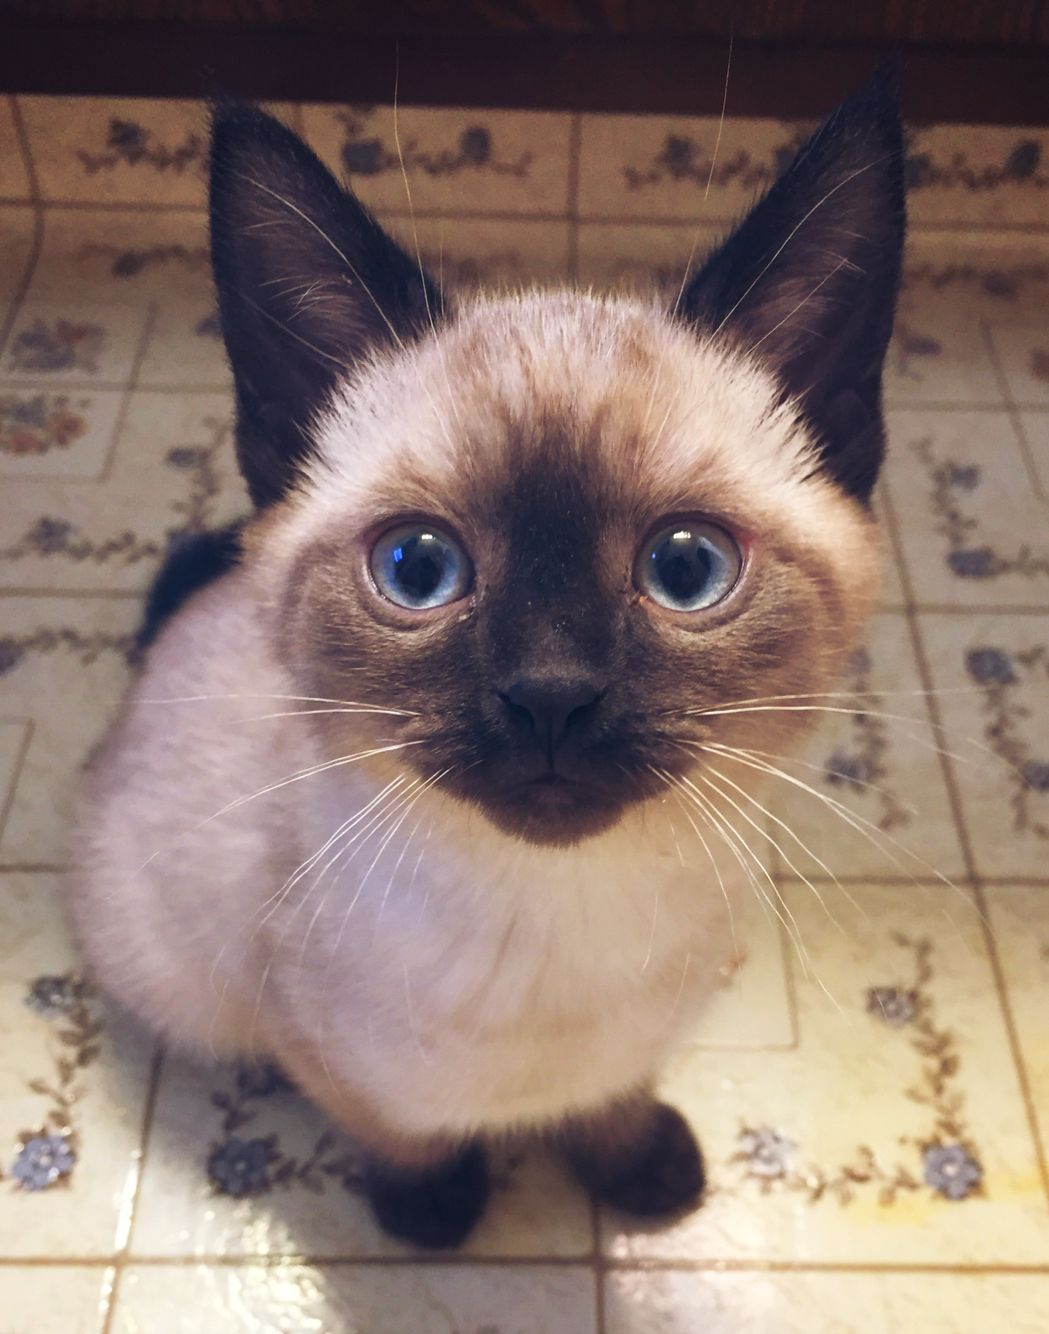

In [3]:
img

In [4]:
dataset.classes

['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']

In [5]:
label

4

In [6]:
from torchvision import transforms

In [8]:
train_transformer = transforms.Compose([
    transforms.Resize([100,100]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transformer = transforms. Compose([
    transforms.Resize([100, 100]),
    transforms.ToTensor()
])

In [9]:
train_transformer(img)

tensor([[[0.0000, 0.1098, 0.1059,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.1098, 0.1098,  ..., 0.1451, 0.1529, 0.1451],
         [0.0000, 0.1098, 0.1098,  ..., 0.1529, 0.1608, 0.1490],
         ...,
         [0.9451, 0.9451, 0.9490,  ..., 0.9529, 0.9569, 0.0000],
         [0.9373, 0.9412, 0.9490,  ..., 0.9608, 0.9647, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.9569, 0.9569, 0.0000]],

        [[0.0000, 0.0706, 0.0706,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0784, 0.0745,  ..., 0.0941, 0.0980, 0.0941],
         [0.0000, 0.0784, 0.0745,  ..., 0.0980, 0.1020, 0.0941],
         ...,
         [0.9059, 0.9020, 0.9020,  ..., 0.8902, 0.8980, 0.0000],
         [0.8941, 0.8941, 0.8980,  ..., 0.8980, 0.9059, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.8941, 0.8863, 0.0000]],

        [[0.0000, 0.1098, 0.1059,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.1098, 0.1098,  ..., 0.1216, 0.1216, 0.1216],
         [0.0000, 0.1098, 0.1098,  ..., 0.1137, 0.1176, 0.

In [10]:
from torch.utils.data import random_split

In [11]:
train_dataset, test_dataset = random_split(dataset,[0.8,0.2])

In [12]:
len(train_dataset)

762

In [13]:
len(test_dataset)

190

In [14]:
from torch.utils.data import Dataset

In [15]:
from torch.utils.data import Dataset

class CatsDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        img, label = self.dataset[index]

        img_cat = self.transformer(img)

        return img_cat, label

In [16]:
train_dataset = CatsDataset(train_dataset, train_transformer)
test_dataset = CatsDataset(test_dataset, test_transformer)

In [17]:
train_dataset[1]

(tensor([[[0.0000, 0.3686, 0.3686,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.3333, 0.3451,  ..., 0.8588, 0.8627, 0.8667],
          [0.0000, 0.3608, 0.3765,  ..., 0.8588, 0.8588, 0.8667],
          ...,
          [0.8706, 0.8627, 0.8549,  ..., 0.9176, 0.9098, 0.0000],
          [0.8588, 0.8549, 0.8588,  ..., 0.8980, 0.8902, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.8824, 0.8784, 0.0000]],
 
         [[0.0000, 0.3255, 0.3294,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.2941, 0.3020,  ..., 0.8431, 0.8431, 0.8353],
          [0.0000, 0.2980, 0.3137,  ..., 0.8431, 0.8392, 0.8314],
          ...,
          [0.8471, 0.8431, 0.8392,  ..., 0.8863, 0.8784, 0.0000],
          [0.8353, 0.8353, 0.8392,  ..., 0.8706, 0.8667, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.8392, 0.8392, 0.0000]],
 
         [[0.0000, 0.3137, 0.3176,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.2627, 0.2784,  ..., 0.8000, 0.8000, 0.8000],
          [0.0000, 0.2706, 0.2902,  ...,

In [19]:
from torch.utils.data import DataLoader

In [20]:
traine_loader = DataLoader(train_dataset, batch_size = 100)
test_loader = DataLoader (test_dataset, batch_size = 100)

In [21]:
from torch import nn

In [22]:
dataset.classes

['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']

In [24]:
for X_batch, y_batch in traine_loader:
    break

In [25]:
3*100*100

30000

In [26]:
model = nn.Sequential(
    nn.Conv2d(kernel_size=3, padding='same', out_channels=10, in_channels=3),  # 10, 400, 400
    nn.ReLU(),
    nn.Conv2d(kernel_size=3, padding='same', out_channels=20, in_channels=10), # 20, 400, 400
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # 20, 200, 200
    nn.Conv2d(kernel_size=3, padding='same', out_channels=20, in_channels=20),  # 20, 200, 200
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # 20, 100, 100
    nn.Conv2d(kernel_size=3, padding='same', out_channels=30, in_channels=20),  # 30, 100, 100
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # 30, 50, 50
    nn.Conv2d(kernel_size=3, padding='same', out_channels=30, in_channels=30),  # 30, 50, 50
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # 30, 25, 25

    nn.Flatten(),   # 18750
    nn.Linear(18750, 5)  # 8 -- кількість порід собак(8 ймовірностей під кожну породу)
)

In [27]:
for x,y in traine_loader:
    break

In [28]:
x.shape

torch.Size([100, 3, 100, 100])

In [29]:
res = model(X_batch)
res.shape

RuntimeError: mat1 and mat2 shapes cannot be multiplied (100x1080 and 18750x5)

In [ ]:
from torch.optim import Adam

# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()


# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = Adam(
    model.parameters(),
    lr=0.0001,
)

In [ ]:
device = "cuda"

model = model.to(device)

In [ ]:
for x,y in traine_loader:
    x = x.to(device)
    y = y.to(device)
    y_pred = model(x)
    loss = loss_fn(y_pred,y)
    print(loss.item())
    
    loss.backward()  
    optimizer.step()  
    optimizer.zero_grad() 

In [ ]:
epochs = 3  # епохи(скільки разів пройтись по всьому датасету під час тренування)

for _ in range(epochs):
    for X_batch, y_batch in traine_loader:
        # підключення до відеокарти
        X_batch = X_batch.to(device)  # зображення
        y_batch = y_batch.to(device)  # індекси породи
    
        # отримати прогноз моделі
        y_pred = model(X_batch)
    
        # обрахунок помилки
        loss = loss_fn(y_pred, y_batch)
    
        print(loss)
    
        # покращення моделі
        loss.backward()  # обрахунок градієнтів
        optimizer.step()  # застосування градієнтів(зміна параметрів моделі)
        optimizer.zero_grad()  #  градієнт очищається
